# Key objective

Determine whether observable player characteristics and behavioral signals can predict whether a player belongs to the High-Value Player (HVP) target class.

### Target Definition: `"High-Value Player"`

**“High-Value Player”** (HVP) is an analytical target created for this modeling exercise based on observed player-level revenue in the current dataset. 

- **Disclaimer 1:** It is not a formal industry definition, does not imply causal value to the game business, and should not be interpreted as a universal definition of a valuable player.

- **Disclaimer 2:** HVP ≠ Behavioral Segment. 

    Behavioral Segments: analytical profiles created in Phase 4–5.

    HVP: a binary target specifically constructed for predictive modeling.

# Executive Summary
- High-Value Player (HVP) is defined for this analysis as the top 10% of players by observed In-App Purchase amount, with a threshold of $214.58. The resulting target consisted of 289 HVPs (10.0%) and 2,599 Non-HVPs (90.0%).

- The model showed limited predictive performance. 
> Its ROC-AUC was 0.498, indicating discrimination close to random.

> At the default 0.5 classification threshold, the model predicted all players as Non-HVP, resulting in 0% precision, recall, and F1-score for HVPs. 

> Predicted probabilities were also nearly identical between actual HVPs and Non-HVPs.

Overall, the available player-level demographic, platform, genre, engagement, and behavioral features did not provide meaningful predictive signal for identifying HVPs with Logistic Regression. 

This result should be interpreted as a limitation of the available data and modeling approach rather than evidence of a causal relationship.

## Setup

In [73]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

#Nhóm chia và kiểm định dữ liệu: sklearn.model_selection

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate)

#Nhóm quản lý quy trình tự động
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Nhóm tiền xử lý dữ liệu
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder)

#Nhóm thuật tuán/Mô hình dự đoán
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Nhóm chỉ số và đồ thị đánh giá
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score, 
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay

)

In [74]:
df = pd.read_csv("../data/game_data_clean.csv")

df["LastPurchaseDate"] = pd.to_datetime(df["LastPurchaseDate"],
    errors="coerce"
)

df.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05


In [75]:
df.dtypes

UserID                                   object
Age                                     float64
Gender                                   object
Country                                  object
Device                                   object
GameGenre                                object
SessionCount                              int64
AverageSessionLength                    float64
SpendingSegment                          object
InAppPurchaseAmount                     float64
FirstPurchaseDaysAfterInstall           float64
PaymentMethod                            object
LastPurchaseDate                 datetime64[ns]
dtype: object

In [76]:
df.shape

(3024, 13)

In [77]:
df.columns

Index(['UserID', 'Age', 'Gender', 'Country', 'Device', 'GameGenre',
       'SessionCount', 'AverageSessionLength', 'SpendingSegment',
       'InAppPurchaseAmount', 'FirstPurchaseDaysAfterInstall', 'PaymentMethod',
       'LastPurchaseDate'],
      dtype='object')

## Define the Modeling Population

In [78]:
# Recheck the missingness of the dataset
df.isna().sum().sort_values(ascending=False)

InAppPurchaseAmount              136
FirstPurchaseDaysAfterInstall    136
PaymentMethod                    136
LastPurchaseDate                 136
Age                               60
Gender                            60
Country                           60
Device                            60
GameGenre                         60
UserID                             0
SessionCount                       0
AverageSessionLength               0
SpendingSegment                    0
dtype: int64

In [79]:
# Select Target-Eligible Popoulation = Exclude those with missing values.
modeling_df = df[
    df["InAppPurchaseAmount"].notna()
].copy()

In [80]:
modeling_df.shape

(2888, 13)

In [81]:
modeling_df["InAppPurchaseAmount"].describe()
# Just 

count    2888.000000
mean      102.582864
std       454.339708
min         0.000000
25%         5.987500
50%        11.975000
75%        17.762500
max      4964.450000
Name: InAppPurchaseAmount, dtype: float64

## Define the HVP Target

In [82]:
# Choose HVP Threshold using IAP variable's distribution
# Reason:
# The revenue distribution is strongly right-skewed, with a relatively small number of players contributing substantially larger observed revenue.
# Therefore, a binary target based on a revenue percentile is more suitable for this classification exercise than treating raw revenue as a normally distributed continuous outcome. 
# This is our threshold.

modeling_df["InAppPurchaseAmount"].describe(
    percentiles=[0.50, 0.75, 0.80, 0.90, 0.95, 0.99]
)

count    2888.000000
mean      102.582864
std       454.339708
min         0.000000
50%        11.975000
75%        17.762500
80%        18.990000
90%       214.576000
95%       375.015500
99%      2876.600400
max      4964.450000
Name: InAppPurchaseAmount, dtype: float64

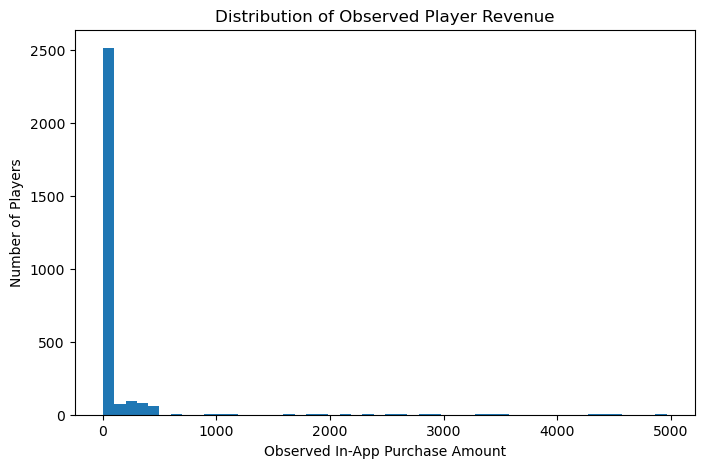

In [83]:
# Visualize for better estimation
plt.figure(figsize=(8, 5))

plt.hist(
    modeling_df["InAppPurchaseAmount"],
    bins=50
)

plt.xlabel("Observed In-App Purchase Amount")
plt.ylabel("Number of Players")
plt.title("Distribution of Observed Player Revenue")

plt.show()

In [84]:
# We should choose the higher percentiles and use a loop to inspect them for the most appropriate threshold.
percentiles = [0.75, 0.80, 0.90, 0.95]

for p in percentiles:
    threshold = modeling_df["InAppPurchaseAmount"].quantile(p)

    print(
        f"Top {(1-p)*100:.0f}% threshold: "
        f"{threshold:.2f}"
    )

threshold_analysis = []

for p in percentiles:
    threshold = modeling_df["InAppPurchaseAmount"].quantile(p)

    count = (
        modeling_df["InAppPurchaseAmount"] >= threshold
    ).sum()

    share = count / len(modeling_df)*100

    threshold_analysis.append({
        "Percentile": p,
        "Threshold": threshold,
        "HVP_Count": count,
        "HVP_Share": share
    })

threshold_analysis = pd.DataFrame(threshold_analysis)

threshold_analysis

Top 25% threshold: 17.76
Top 20% threshold: 18.99
Top 10% threshold: 214.58
Top 5% threshold: 375.02


,Percentile,Threshold,HVP_Count,HVP_Share
0,0.75,17.7625,722,25.000000
1,0.80,18.9900,579,20.048476
2,0.90,214.5760,289,10.006925
3,0.95,375.0155,145,5.020776


### Target selection rationale:
- The top 10% revenue percentile was selected as the threshold for defining High-Value Players (HVP). The observed revenue distribution shows a relatively small difference between the 25th and 20th percentile thresholds ($17.76 vs. $18.99), while the threshold increases substantially at the 90th percentile to $214.58.
- This creates a clearer separation between the majority of players and a smaller group with substantially higher observed purchase amounts. 
- The top 5% threshold ($375.02) is considerably more restrictive, so the top 10% threshold was selected to capture a sufficiently small high-value group while retaining more observations for classification modeling.

In [85]:
HVP_PERCENTILE = 0.90

HVP_THRESHOLD = modeling_df[
    "InAppPurchaseAmount"
].quantile(HVP_PERCENTILE)

modeling_df["HVP"] = (
    modeling_df["InAppPurchaseAmount"] >= HVP_THRESHOLD
).astype(int)

In [86]:
# Valudate Target

target_summary = (
    modeling_df["HVP"]
    .value_counts()
    .rename_axis("HVP")
    .reset_index(name="Players")
)

target_summary["Share"] = (
    target_summary["Players"]
    / target_summary["Players"].sum()*100
)

target_summary


,HVP,Players,Share
0,0,2599,89.993075
1,1,289,10.006925


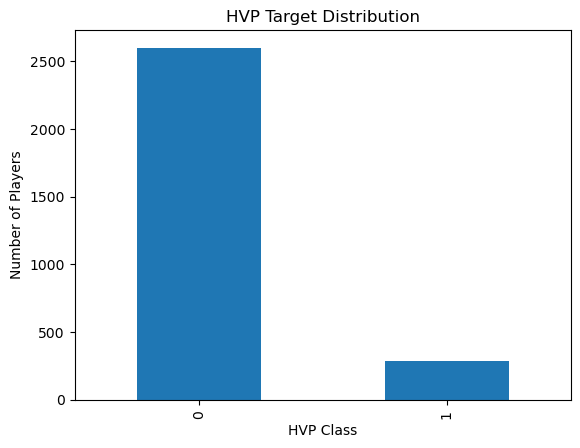

In [87]:
target_summary.plot(
    x="HVP",
    y="Players",
    kind="bar",
    legend=False
)

plt.title("HVP Target Distribution")
plt.xlabel("HVP Class")
plt.ylabel("Number of Players")

plt.show()

## Define Predictive Features

### Candidate Predictive Features

The candidate features represent information about the player that may help
identify HVP membership.

#### Engagement
- SessionCount
- AverageSessionLength

#### Player Characteristics
- Age
- Gender
- Country

#### Game / Platform Context
- Device
- GameGenre

#### Observed Purchase Behavior
- FirstPurchaseDaysAfterInstall = Purchase Timing
- PurchaseRecencyDays
- PaymentMethod

These features describe player characteristics and observed behavior.

**Also, leakager variables are removed:**
- `InAppPurchaseAmount` -> This one is used to construct the HVP target.
- `LogRevenue` -> This is a transformation of the same information.
- `BehavioralSegment` -> This is a descriptive grouping from previous phases. Not an independent predictive feature.

In [88]:
# Recreate Purchase Recency
reference_date = modeling_df["LastPurchaseDate"].max()

modeling_df["PurchaseRecencyDays"] = (
    reference_date - modeling_df["LastPurchaseDate"]
).dt.days



In [89]:
target = "HVP"

feature_columns = [
    "Age",
    "Gender",
    "Country",
    "Device",
    "GameGenre",
    "SessionCount",
    "AverageSessionLength",
    "FirstPurchaseDaysAfterInstall",
    "PurchaseRecencyDays",
    "PaymentMethod"
]

X = modeling_df[feature_columns].copy()
y = modeling_df[target].copy()

### Information-Timing Limitation

The current dataset contains aggregated player-level information rather than
a complete event-level timeline.

Some candidate predictors, such as purchase timing and purchase recency,
are only available after the player has generated observable purchase
activity.

Therefore, this model should not be interpreted as a model that predicts
which newly acquired players will eventually become high-value players.

Instead, the scope is:

> Classify players into the analytically defined HVP class using available
> player-level characteristics and observed behavioral signals.

## Prepare Train/Test Data

In [90]:
# Split the data into train/test sét

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [91]:
# Check the status of each set

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (2310, 10)
Test set: (578, 10)

Training target distribution:
HVP
0    0.9
1    0.1
Name: proportion, dtype: float64

Test target distribution:
HVP
0    0.899654
1    0.100346
Name: proportion, dtype: float64


## Build Preprocessing Pipeline

In [92]:
# Identify feature types
numeric_features = [
    "Age",
    "SessionCount",
    "AverageSessionLength",
    "FirstPurchaseDaysAfterInstall",
    "PurchaseRecencyDays"
]

categorical_features = [
    "Gender",
    "Country",
    "Device",
    "GameGenre",
    "PaymentMethod"
]

In [93]:
# Numeric Pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

#Categorical Pipeline
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## Logistic Regression Model Training

Logistic Regression is used as the baseline classification model.

It is appropriate because:

- the target is binary; also, the player behavior is not linear
- it provides probability estimates;
- its coefficients can be interpreted;
- it provides a simple benchmark for a more complex model.

In [94]:
# Build pipleine
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [96]:
# Predict
y_pred_logistic = logistic_model.predict(X_test)

y_prob_logistic = logistic_model.predict_proba(
    X_test
)[:, 1]

# Evaluate the accuracy of the model
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

# Logistic results
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic,
    y_prob_logistic
)

logistic_results

/opt/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'Model': 'Logistic Regression',
 'Accuracy': 0.8996539792387543,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC_AUC': 0.45633289124668436,
 'PR_AUC': 0.12451752777557423}

In [98]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

           0       0.90      1.00      0.95       520
           1       0.00      0.00      0.00        58

    accuracy                           0.90       578
   macro avg       0.45      0.50      0.47       578
weighted avg       0.81      0.90      0.85       578



/opt/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [122]:
probability_analysis = pd.DataFrame({
    "Actual_HVP": y.values,
    "Predicted_Probability": cv_prob
})

probability_analysis.groupby("Actual_HVP")[
    "Predicted_Probability"
].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
Actual_HVP,,,,,
0,2599,0.100263,0.091882,0.018400,0.350176
1,289,0.099625,0.091792,0.021054,0.288122


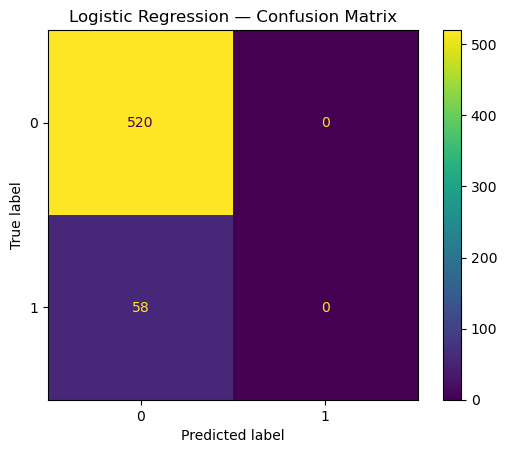

In [99]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic
)

plt.title("Logistic Regression — Confusion Matrix")
plt.show()

## Cross-Validation for Logistic Regression

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_results_logistic = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

{
    metric: cv_results_logistic[
        f"test_{metric}"
    ].mean()
    for metric in scoring
}
cv_summary_logistic = pd.DataFrame({
    metric: [
        cv_results_logistic[f"test_{metric}"].mean(),
        cv_results_logistic[f"test_{metric}"].std()
    ]
    for metric in scoring
}, index=["Mean", "Std"])

cv_summary_logistic


/opt/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/minicond

,accuracy,precision,recall,f1,roc_auc
Mean,0.899931,0.0,0.0,0.0,0.497566
Std,0.000645,0.0,0.0,0.0,0.062403


In [119]:
print("Class distribution:")
print(y.value_counts())

print("\nClass distribution (%):")
print(y.value_counts(normalize=True) * 100)

print("\nHVP threshold:")
print(HVP_THRESHOLD)

print("\nTarget dtype:")
print(y.dtype)

Class distribution:
HVP
0    2599
1     289
Name: count, dtype: int64

Class distribution (%):
HVP
0    89.993075
1    10.006925
Name: proportion, dtype: float64

HVP threshold:
214.57600000000002

Target dtype:
int64


In [120]:
# Check predictions on each CV fold
from sklearn.model_selection import cross_val_predict

cv_pred = cross_val_predict(
    logistic_model,
    X,
    y,
    cv=cv,
    method="predict"
)

print("CV prediction distribution:")
print(pd.Series(cv_pred).value_counts())

print("\nCV prediction distribution (%):")
print(pd.Series(cv_pred).value_counts(normalize=True) * 100)

CV prediction distribution:
0    2888
Name: count, dtype: int64

CV prediction distribution (%):
0    100.0
Name: proportion, dtype: float64


In [121]:
cv_prob = cross_val_predict(
    logistic_model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

print("Predicted probability summary:")
print(pd.Series(cv_prob).describe())

print("\nHighest predicted probabilities:")
print(
    pd.Series(cv_prob)
    .sort_values(ascending=False)
    .head(20)
)

Predicted probability summary:
count    2888.000000
mean        0.100200
std         0.043274
min         0.018400
25%         0.069303
50%         0.091852
75%         0.122169
max         0.350176
dtype: float64

Highest predicted probabilities:
196     0.350176
1590    0.331291
2561    0.330717
2191    0.316133
107     0.292642
990     0.292063
622     0.288122
305     0.287209
161     0.279250
1637    0.278874
1962    0.277328
1355    0.273289
36      0.269616
119     0.268940
390     0.265694
1312    0.259255
1967    0.255435
1435    0.254772
2172    0.252152
988     0.245295
dtype: float64


## Visualization


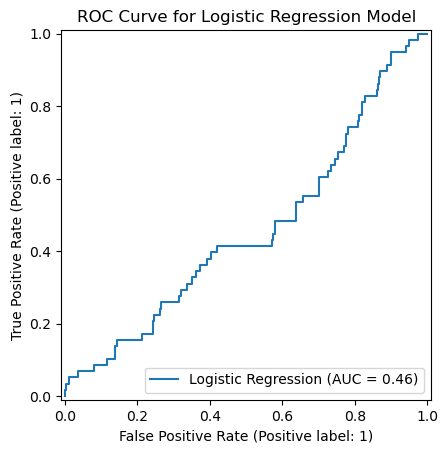

In [104]:
# ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

plt.title("ROC Curve for Logistic Regression Model")
plt.show()

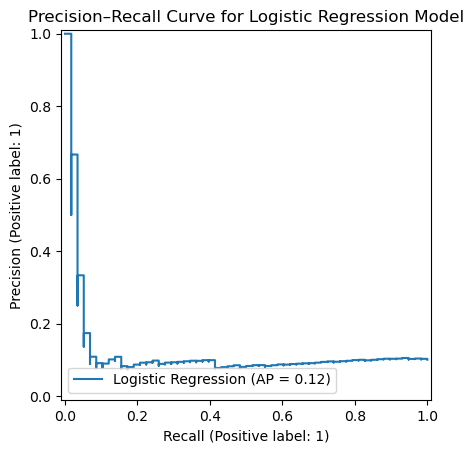

In [105]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

plt.title("Precision–Recall Curve for Logistic Regression Model")
plt.show()

## Feature Interpretation

In [106]:
# Create coefficient table

## Extract feature names
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

## Extract coefficients
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["AbsCoefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "AbsCoefficient",
    ascending=False
)

coefficient_df.head(20)

,Feature,Coefficient,AbsCoefficient
23,cat__Country_Netherlands,-0.797715,0.797715
8,cat__Country_Afghanistan,0.782651,0.782651
10,cat__Country_Bangladesh,0.551619,0.551619
14,cat__Country_Denmark,-0.495873,0.495873
24,cat__Country_Norway,-0.446960,0.446960
42,cat__GameGenre_Fighting,0.439787,0.439787
32,cat__Country_Turkey,-0.427735,0.427735
45,cat__GameGenre_Puzzle,-0.424653,0.424653
33,cat__Country_UK,-0.402552,0.402552
7,cat__Gender_Other,-0.401512,0.401512


## Error Analysis

In [108]:
test_analysis = X_test.copy()

test_analysis["ActualHVP"] = y_test.values
test_analysis["PredictedHVP"] = y_pred_logistic
test_analysis["HVPProbability"] = y_prob_logistic

In [111]:
# False positives
false_positive = test_analysis[
    (test_analysis["ActualHVP"] == 0) &
    (test_analysis["PredictedHVP"] == 1)
].copy()

# False negatives
false_negative = test_analysis[
    (test_analysis["ActualHVP"] == 1) &
    (test_analysis["PredictedHVP"] == 0)
].copy()

In [ ]:
# Profile model errors
error_profile = pd.DataFrame({
    "Group": [
        "False Positive",
        "False Negative"
    ],
    "Players": [
        len(false_positive),
        len(false_negative)
    ]
})

error_profile

,Group,Players
0,False Positive,0
1,False Negative,58


In [ ]:
# Compare errors in different features

error_groups = {
    "False Positive": false_positive,
    "False Negative": false_negative
}

for group_name, group_df in error_groups.items():
    print(f"\n{group_name}")
    print(
        group_df[
            [
                "SessionCount",
                "AverageSessionLength",
                "FirstPurchaseDaysAfterInstall",
                "PurchaseRecencyDays"
            ]
        ].describe()
    )


False Positive
       SessionCount  AverageSessionLength  FirstPurchaseDaysAfterInstall  \
count           0.0                   0.0                            0.0   
mean            NaN                   NaN                            NaN   
std             NaN                   NaN                            NaN   
min             NaN                   NaN                            NaN   
25%             NaN                   NaN                            NaN   
50%             NaN                   NaN                            NaN   
75%             NaN                   NaN                            NaN   
max             NaN                   NaN                            NaN   

       PurchaseRecencyDays  
count                  0.0  
mean                   NaN  
std                    NaN  
min                    NaN  
25%                    NaN  
50%                    NaN  
75%                    NaN  
max                    NaN  

False Negative
       SessionCount  A

## Post-Model Interpretation

The Behavioral Segments developed in previous phases are used here only
to interpret the composition of model predictions.

They were not used to construct the HVP target and were excluded from
the predictive feature set.

This allows us to ask:

> What behavioral profiles are represented among players that the model
> identifies as HVPs?

This is a descriptive post-model analysis rather than part of the
prediction mechanism.

In [115]:
# Recreate behavioral segment

# Work only with players who have observed IAP values
behavior_df = df[df["InAppPurchaseAmount"].notna()].copy()

# 1. Transform revenue to reduce the effect of extreme values
behavior_df["LogRevenue"] = np.log1p(
    behavior_df["InAppPurchaseAmount"]
)

# 2. Standardize engagement variables
behavior_df["SessionCount_Z"] = (
    behavior_df["SessionCount"] - behavior_df["SessionCount"].mean()
) / behavior_df["SessionCount"].std()

behavior_df["SessionLength_Z"] = (
    behavior_df["AverageSessionLength"]
    - behavior_df["AverageSessionLength"].mean()
) / behavior_df["AverageSessionLength"].std()

# 3. Create an overall Engagement Score
behavior_df["EngagementScore"] = (
    behavior_df["SessionCount_Z"]
    + behavior_df["SessionLength_Z"]
) / 2

# 4. Define median thresholds
engagement_threshold = behavior_df["EngagementScore"].median()
monetization_threshold = behavior_df["LogRevenue"].median()

# 5. Create Behavioral Segments
behavior_df["BehavioralSegment"] = np.select(
    [
        (behavior_df["EngagementScore"] >= engagement_threshold) &
        (behavior_df["LogRevenue"] >= monetization_threshold),

        (behavior_df["EngagementScore"] >= engagement_threshold) &
        (behavior_df["LogRevenue"] < monetization_threshold),

        (behavior_df["EngagementScore"] < engagement_threshold) &
        (behavior_df["LogRevenue"] >= monetization_threshold),

        (behavior_df["EngagementScore"] < engagement_threshold) &
        (behavior_df["LogRevenue"] < monetization_threshold)
    ],
    [
        "High Engagement - High Monetization",
        "High Engagement - Low Monetization",
        "Low Engagement - High Monetization",
        "Low Engagement - Low Monetization"
    ],
    default="Unknown"
)

# 6. Check the resulting segments
behavior_df["BehavioralSegment"].value_counts()

BehavioralSegment
Low Engagement - Low Monetization      733
High Engagement - High Monetization    733
High Engagement - Low Monetization     711
Low Engagement - High Monetization     711
Name: count, dtype: int64

In [118]:
test_with_segment = test_analysis.copy()

test_with_segment["BehavioralSegment"] = (
    behavior_df.loc[
        test_with_segment.index,
        "BehavioralSegment"
    ]
)

pd.crosstab(
    test_with_segment["BehavioralSegment"],
    test_with_segment["PredictedHVP"],
    normalize="index"
)


PredictedHVP,0
BehavioralSegment,
High Engagement - High Monetization,1.0
High Engagement - Low Monetization,1.0
Low Engagement - High Monetization,1.0
Low Engagement - Low Monetization,1.0


## Key Findings

### 1. HVP Target Definition

* **High-Value Player (HVP)** was defined specifically for this modeling exercise as players in the **top 10% of observed IAP**.
* The resulting threshold was **$214.58**.
* This produced **289 HVPs (10.01%)** and **2,599 Non-HVPs (89.99%)**.
* HVP is an **analytical modeling label**, not a universal industry definition of player value.

### 2. Logistic Regression Performance

* Logistic Regression was unable to meaningfully distinguish HVPs from Non-HVPs using the available player-level features.
* **ROC-AUC: 0.498**, approximately random discrimination.
* The model predicted **100% of players as Non-HVP** at the default 0.5 threshold.
* Consequently, HVP performance was:

  * **Precision: 0.00**
  * **Recall: 0.00**
  * **F1-score: 0.00**
* Overall accuracy was **90%**, but this was largely driven by the 90% Non-HVP class and therefore was not informative about HVP detection.

### 3. Predicted Probability Analysis

* Predicted probabilities were almost identical between actual HVPs and Non-HVPs:

  * Non-HVP mean: **0.1003**
  * HVP mean: **0.0996**
* Median probabilities were also almost identical (**0.0919 vs. 0.0918**).
* This supports the conclusion that the model did **not identify a meaningful probability-based separation** between the two groups.

### 4. Error Analysis

* **False positives: 0**, because the model produced no positive HVP predictions.
* **False negatives: 58** in the test set, meaning all actual HVPs were classified as Non-HVP.
* These missed HVPs averaged:

  * **10.57 sessions**
  * **19.50 minutes/session**
  * **16.64 days to first purchase**
  * **100.81 days of purchase recency**
* No single obvious behavioral pattern emerged from these false negatives.

### 5. Overall Modeling Finding

> **The available player-level demographic, platform, genre, engagement, and observed behavioral features did not provide meaningful predictive signal for identifying the analytically defined HVP group using Logistic Regression.**

This finding is **descriptive/predictive rather than causal**: it does not imply that these characteristics have no effect on player spending.

### 6. Project-Level Takeaway

* Earlier analysis showed that monetization is **highly concentrated among a small group of players**, while simple engagement metrics have only limited linear association with observed revenue.
* The predictive modeling results reinforce this pattern: **high observed monetization cannot be reliably identified from the available player-level features alone**.
* A stronger predictive model would likely require richer information, such as **event-level player behavior, transaction history, progression, session-level activity, or time-series data**, which are not available in this dataset.
